# Simulation Attribution Results

Inspect the CSV outputs produced by:

```bash
python scripts/simulation/generate_data.py --minimal --overwrite
python scripts/simulation/run_attribution.py --config configs/simulation_attribution/minimal.yaml --overwrite
python scripts/simulation/summarize_attribution.py
```

## Load Results

In [8]:
import os
import tempfile
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "axiom_interp_matplotlib"))

import matplotlib.pyplot as plt
import pandas as pd


def find_repo_root(start: Path = Path.cwd()) -> Path:
    for path in (start, *start.parents):
        if (path / "simulation_data.py").exists() and (path / "results").exists():
            return path
    raise FileNotFoundError("Run this notebook from inside the repository checkout.")


ROOT = find_repo_root()
RESULTS = ROOT / "results" / "simulation_attribution"
SUMMARY_PATH = RESULTS / "summaries" / "summary.csv"
METRICS_DIR = RESULTS / "metrics"
RAW_DIR = RESULTS / "raw_scores"

assert SUMMARY_PATH.exists(), f"Missing {SUMMARY_PATH}. Run summarize_attribution.py first."
assert any(METRICS_DIR.glob("*.csv")), f"Missing metric CSVs under {METRICS_DIR}."
assert any(RAW_DIR.glob("*.csv")), f"Missing raw score CSVs under {RAW_DIR}."

summary = pd.read_csv(SUMMARY_PATH)
metrics = pd.concat((pd.read_csv(path) for path in sorted(METRICS_DIR.glob("*.csv"))), ignore_index=True)
raw = pd.concat((pd.read_csv(path) for path in sorted(RAW_DIR.glob("*.csv"))), ignore_index=True)

summary.shape, metrics.shape, raw.shape

((14, 10), (42, 16), (420, 15))

## Method Summary

Use `summary.csv` for dataset-level method comparison. Higher `mean_top_k_recall` and lower noise attribution are usually better.

In [2]:
summary.sort_values(
    ["dataset_type", "mean_top_k_recall", "mean_abs_noise"],
    ascending=[True, False, True],
)

,dataset_type,method,n_rows,mean_top_k_recall,mean_abs_relevant,mean_abs_noise,mean_max_abs_noise,mean_baseline_efficiency_gap,mean_injected_null,mean_stability_lipschitz
0,linear_additive,baseline_minshap,3,1.000000,3.491554,0.000000,0.000000,NaN,NaN,NaN
1,linear_additive,baseline_shap,3,1.000000,3.491554,0.000000,0.000000,0.000000e+00,NaN,NaN
2,linear_additive,integrated_gradients,3,1.000000,3.491554,0.000000,0.000000,1.869112e-11,NaN,NaN
4,linear_additive,marginal_shap,3,0.916667,3.211737,0.341750,0.644192,NaN,NaN,NaN
3,linear_additive,marginal_minshap,3,0.250000,3.093029,3.400160,6.141545,NaN,NaN,NaN
5,product_interaction,baseline_minshap,3,1.000000,1.010405,0.000000,0.000000,NaN,NaN,NaN
6,product_interaction,baseline_shap,3,1.000000,1.719946,0.000000,0.000000,0.000000e+00,NaN,NaN
7,product_interaction,integrated_gradients,3,1.000000,1.719946,0.000000,0.000000,3.772390e-12,NaN,NaN
9,product_interaction,marginal_shap,3,0.833333,1.738621,0.189682,0.417282,NaN,NaN,NaN
8,product_interaction,marginal_minshap,3,0.500000,2.411053,2.191165,3.524697,NaN,NaN,NaN


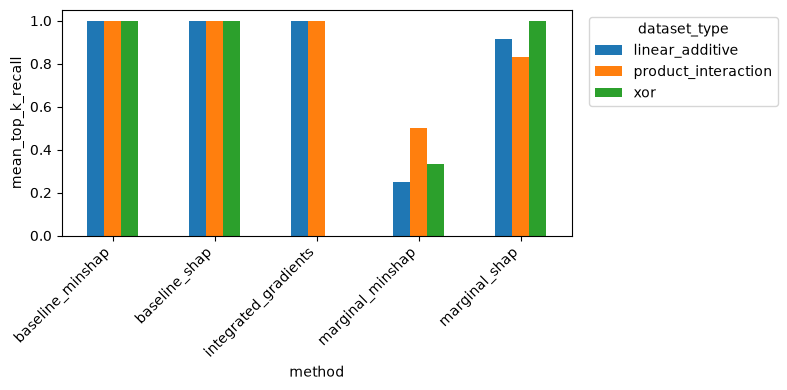

In [4]:
pivot = summary.pivot(index="method", columns="dataset_type", values="mean_top_k_recall")
ax = pivot.plot.bar(figsize=(8, 4))
ax.set_ylabel("mean_top_k_recall")
ax.set_ylim(0, 1.05)
ax.legend(title="dataset_type", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

## Row-Level Metrics

Use `metrics/*.csv` to inspect method behavior on individual input rows.

In [5]:
metric_cols = [
    "dataset_type",
    "method",
    "row_id",
    "top_k_recall",
    "mean_abs_relevant",
    "mean_abs_noise",
    "max_abs_noise",
    "baseline_efficiency_gap",
    "oracle_max_abs_error",
]

metrics[metric_cols].sort_values(["dataset_type", "method", "row_id"])

,dataset_type,method,row_id,top_k_recall,mean_abs_relevant,mean_abs_noise,max_abs_noise,baseline_efficiency_gap,oracle_max_abs_error
1,linear_additive,baseline_minshap,0,1.00,4.018710,0.000000,0.000000,NaN,0.0
6,linear_additive,baseline_minshap,1,1.00,2.229933,0.000000,0.000000,NaN,0.0
11,linear_additive,baseline_minshap,2,1.00,4.226018,0.000000,0.000000,NaN,0.0
0,linear_additive,baseline_shap,0,1.00,4.018710,0.000000,0.000000,0.000000e+00,0.0
5,linear_additive,baseline_shap,1,1.00,2.229933,0.000000,0.000000,0.000000e+00,0.0
10,linear_additive,baseline_shap,2,1.00,4.226018,0.000000,0.000000,0.000000e+00,0.0
4,linear_additive,integrated_gradients,0,1.00,4.018710,0.000000,0.000000,2.351896e-12,0.0
9,linear_additive,integrated_gradients,1,1.00,2.229933,0.000000,0.000000,9.583445e-12,0.0
14,linear_additive,integrated_gradients,2,1.00,4.226018,0.000000,0.000000,4.413803e-11,0.0
3,linear_additive,marginal_minshap,0,0.50,2.899641,2.663681,3.522336,NaN,0.0


## Feature Scores For One Row

Use `raw_scores/*.csv` to inspect concrete feature attributions. Relevant features are blue; noise features are gray.

In [ ]:
dataset = "linear_additive"
method = "baseline_shap"
row_id = 0

one = raw.query("dataset_type == @dataset and method == @method and row_id == @row_id").copy()

one.sort_values("abs_score", ascending=False)[
    ["feature", "score", "abs_score", "is_relevant", "is_noise", "is_additive", "is_interaction_member"]
]

,feature,score,abs_score,is_relevant,is_noise,is_additive,is_interaction_member
0,0,7.056209,7.056209,1,0,1,0
3,3,4.481786,4.481786,1,0,1,0
2,2,2.936214,2.936214,1,0,1,0
1,1,1.600629,1.600629,1,0,1,0
4,4,0.000000,0.000000,0,1,0,0
5,5,0.000000,0.000000,0,1,0,0
6,6,0.000000,0.000000,0,1,0,0
7,7,0.000000,0.000000,0,1,0,0
8,8,0.000000,0.000000,0,1,0,0
9,9,0.000000,0.000000,0,1,0,0


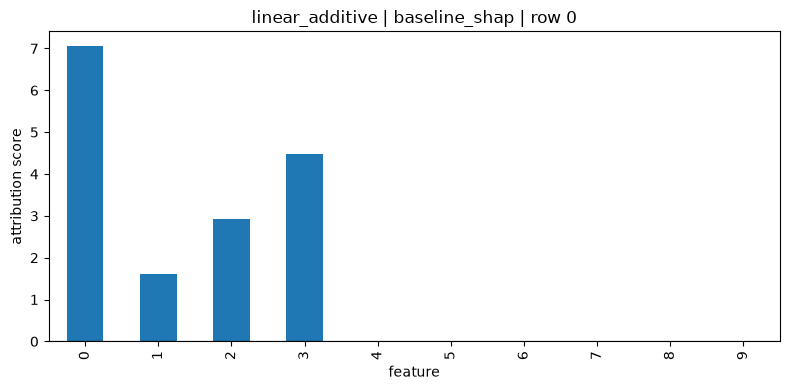

In [7]:
plot_df = one.sort_values("feature")
colors = plot_df["is_relevant"].map({1: "tab:blue", 0: "tab:gray"})

ax = plot_df.plot.bar(x="feature", y="score", color=colors, legend=False, figsize=(8, 4))
ax.axhline(0, color="black", linewidth=0.8)
ax.set_title(f"{dataset} | {method} | row {row_id}")
ax.set_ylabel("attribution score")
plt.tight_layout()